# Hands-on thermal FEM for a thermally tuned ring resonator

## Goal

This tutorial reconstructs the **physical design** from Flexcompute's public
`ThermallyTunedRingResonator` example: a silicon ring, two bus waveguides, a
100 nm coupling gap, and a notched TiN heater embedded in silica. We then solve
the public example's $x=0$ vertical $y$-$z$ section with femx's native JAX
linear-triangle heat operator and differentiate the converged state with an
implicit adjoint.

**What you will build**

1. A boundary-aligned, tagged P1 triangular mesh.
2. The weak-form matrix for conduction with Dirichlet and Robin boundaries.
3. A float64 JAX solve with residual and energy-balance checks.
4. A reverse-mode gradient checked against central finite differences.

> **Evidence level:** this is a verified 2D numerical tutorial. It does not claim
> parity with the full 3D Tidy3D heat result, same-mesh Elmer agreement, or measured
> device prediction.

## 1. Public source and clean-room boundary

The design is traced to the [Flexcompute example](https://www.flexcompute.com/tidy3d/examples/notebooks/ThermallyTunedRingResonator/) and its
[public notebook repository](https://github.com/flexcompute/tidy3d-notebooks). This notebook independently
implements the published numerical dimensions and boundary conditions. It does not
copy source code, prose, figures, cloud outputs, task identifiers, or credentials
from the original notebook.

The material values below are **tutorial parameters from that public example**.
They are not promoted to authoritative femx catalog records or foundry-calibrated
thin-film properties. Heat capacity is listed for traceability but is not used in a
steady-state solve.

## 2. Setup

Run from the repository root in an environment containing femx's JAX and notebook
dependencies. The portable default is CPU; request CUDA explicitly before the kernel
starts:

```bash
FEMX_NOTEBOOK_PLATFORM=cuda jupyter nbconvert --execute --to notebook --inplace \
  examples/thermally_tuned_ring_fem.ipynb
```

The requested backend is strict: no silent CPU fallback is allowed. Every FEM array
uses float64 so that later Elmer comparisons do not mix scalar precision.

In [1]:
# ruff: noqa: E402  # Select the JAX platform before importing JAX.

import gc
import hashlib
import json
import os
import sys
import time
from pathlib import Path

REQUESTED_PLATFORM = os.environ.get("FEMX_NOTEBOOK_PLATFORM", "cpu").strip().lower()
if REQUESTED_PLATFORM not in {"cuda", "cpu"}:
    raise ValueError("FEMX_NOTEBOOK_PLATFORM must be 'cuda' or 'cpu'")

if "jax" not in sys.modules:
    os.environ["JAX_PLATFORMS"] = REQUESTED_PLATFORM
    os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
    if REQUESTED_PLATFORM == "cuda":
        os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")

import jax

jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np
from matplotlib.patches import Rectangle, Wedge

expected_backend = {"cuda": "gpu", "cpu": "cpu"}[REQUESTED_PLATFORM]
if jax.default_backend() != expected_backend:
    raise RuntimeError(
        f"requested {REQUESTED_PLATFORM!r}, but JAX initialized "
        f"{jax.default_backend()!r}; restart after fixing the runtime"
    )
if not jax.config.x64_enabled:
    raise RuntimeError("float64 is required for the femx/Elmer numerical contract")


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "src/femx").is_dir():
            return candidate
    raise RuntimeError("run this notebook from inside the femx checkout")


REPO_ROOT = find_repo_root(Path.cwd().resolve())
SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from femx.backends._scalar_h1 import validate_planar_triangle_mesh
from femx.backends.jax.autodiff import implicit_linear_solve
from femx.backends.jax.operators import (
    AssembledScalarSystem,
    assemble_steady_heat_system,
    impose_dirichlet_constraints,
    triangle_p1_geometry,
)
from femx.mesh import CellType, EntityTag, Mesh, MeshGeometry, MeshTopology

DEVICE = jax.devices()[0]
RUNTIME = {
    "jax_version": jax.__version__,
    "backend": jax.default_backend(),
    "device_kind": str(getattr(DEVICE, "device_kind", DEVICE)),
    "float64": bool(jax.config.x64_enabled),
}
for key, value in RUNTIME.items():
    print(f"{key:12s}: {value}")

jax_version : 0.11.0
backend     : gpu
device_kind : NVIDIA GeForce RTX 5070 Ti
float64     : True


## 3. Reconstruct the published design

All dimensions are in micrometres. Device silicon occupies
$0\le z\le0.22$, the silicon wafer occupies $-2.5\le z\le-2.0$, and
silica fills the remaining solid region up to $z=2.8$.

- Silicon ring: centre-line radius 5, width 0.5, height 0.22.
- Two buses: width 0.5, centred at $y=\pm5.6$; the edge gap is 0.1.
- TiN heater: annulus from radius 4 to 6, height 0.14,
  $2.22\le z\le2.36$.
- Heater notch: subtract a $(1,3,0.21)$ box centred at $(0,-5,2.29)$.
- Thermal lateral domain: $20\times20$.

The Boolean masks below are an independent analytic reconstruction. The $x=0$ section
crosses both buses and both coupling gaps. The notch removes the negative-$y$ heater
segment from this section, leaving the positive-$y$ heater segment only.

In [2]:
SOURCE_PAGE = "https://www.flexcompute.com/tidy3d/examples/notebooks/ThermallyTunedRingResonator/"
SOURCE_REPOSITORY = "https://github.com/flexcompute/tidy3d-notebooks"

DESIGN = {
    "wavelength_um": 1.55,
    "ring_radius_um": 5.0,
    "waveguide_width_um": 0.5,
    "waveguide_height_um": 0.22,
    "coupling_gap_um": 0.1,
    "bus_center_y_um": (-5.6, 5.6),
    "box_thickness_um": 2.0,
    "cladding_top_z_um": 2.8,
    "wafer_thickness_um": 0.5,
    "heater_width_um": 2.0,
    "heater_height_um": 0.14,
    "heater_vertical_gap_um": 2.0,
    "heater_center_z_um": 2.29,
    "heater_notch_center_um": (0.0, -5.0, 2.29),
    "heater_notch_size_um": (1.0, 3.0, 0.21),
    "heat_domain_xy_um": (20.0, 20.0),
}

MATERIALS = {
    "Si": {
        "n_at_1p55um": 3.4777,
        "dn_dT_per_K": 1.86e-4,
        "thermal_conductivity_W_per_mK": 148.0,
        "heat_capacity_J_per_kgK": 710.0,
    },
    "SiO2": {
        "n_at_1p55um": 1.444,
        "dn_dT_per_K": 1.0e-5,
        "thermal_conductivity_W_per_mK": 1.38,
        "heat_capacity_J_per_kgK": 709.0,
    },
    "TiN": {
        "thermal_conductivity_W_per_mK": 28.0,
        "heat_capacity_J_per_kgK": 598.0,
        "electrical_conductivity_S_per_m": 2.3e6,
        "optical_model_in_source_tutorial": "PEC",
    },
}

HEAT = {
    "ambient_temperature_K": 300.0,
    "convection_W_per_m2K": 10.0,
    "current_A": float(os.environ.get("FEMX_MRR_CURRENT_MA", "15.0")) * 1.0e-3,
}
if HEAT["current_A"] <= 0.0:
    raise ValueError("FEMX_MRR_CURRENT_MA must be positive")

MESH_PROFILE = os.environ.get("FEMX_MRR_MESH_PROFILE", "standard").strip().lower()
if MESH_PROFILE not in {"standard", "fine"}:
    raise ValueError("FEMX_MRR_MESH_PROFILE must be 'standard' or 'fine'")

OPTICAL_TARGET = {
    "domain_xyz_um": (14.0, 14.0, 3.0),
    "wavelength_range_um": (1.5, 1.6),
    "mode_source_center_um": (-6.8, 5.6, 0.11),
    "through_monitor_center_um": (6.8, 5.6, 0.11),
    "drop_monitor_center_um": (-6.8, -5.6, 0.11),
    "ring_mode_plane_center_um": (-5.0, 0.0, 0.11),
    "ring_mode_bend_radius_um": 5.0,
}


def silicon_plan_mask(x_um, y_um):
    radius = np.hypot(x_um, y_um)
    ring = (radius >= 4.75) & (radius <= 5.25)
    buses = (np.abs(y_um - 5.6) <= 0.25) | (np.abs(y_um + 5.6) <= 0.25)
    return ring | buses


def heater_plan_mask(x_um, y_um):
    radius = np.hypot(x_um, y_um)
    annulus = (radius >= 4.0) & (radius <= 6.0)
    notch = (np.abs(x_um) <= 0.5) & (y_um >= -6.5) & (y_um <= -3.5)
    return annulus & ~notch


design_record = {
    "schema_version": "femx.example.thermally_tuned_ring_fem/v1",
    "source_page": SOURCE_PAGE,
    "design": DESIGN,
    "materials": MATERIALS,
    "heat": HEAT,
    "optical_target": OPTICAL_TARGET,
    "model": "exact analytic 3D design; reduced x=0 2D solid thermal solve",
}
design_json = json.dumps(design_record, sort_keys=True, separators=(",", ":"), ensure_ascii=True)
DESIGN_SHA256 = hashlib.sha256(design_json.encode("utf-8")).hexdigest()

assert np.isclose(5.6 - 0.25 - 5.25, 0.1)
assert heater_plan_mask(np.asarray([5.0]), np.asarray([0.0])).item()
assert not heater_plan_mask(np.asarray([0.0]), np.asarray([-5.0])).item()
assert not heater_plan_mask(np.asarray([0.0]), np.asarray([0.0])).item()
assert heater_plan_mask(np.asarray([0.0]), np.asarray([5.0])).item()
assert silicon_plan_mask(np.asarray([0.0]), np.asarray([5.0])).item()
assert silicon_plan_mask(np.asarray([0.0]), np.asarray([5.6])).item()
print(f"design schema : {design_record['schema_version']}")
print(f"design digest : {DESIGN_SHA256}")
print("ring / bus    : R=5 µm, width=0.5 µm, edge gap=0.1 µm")
print("heater        : R=4..6 µm, z=2.22..2.36 µm, exact lower notch")
print("optic target  : 14 x 14 x 3 µm, 1.5..1.6 µm")
print(f"current / mesh: {HEAT['current_A'] * 1e3:g} mA / {MESH_PROFILE}")

design schema : femx.example.thermally_tuned_ring_fem/v1
design digest : 169ba88479b175284fc09749ad842a463280f7ece758e1513695b362c1bb3f86
ring / bus    : R=5 µm, width=0.5 µm, edge gap=0.1 µm
heater        : R=4..6 µm, z=2.22..2.36 µm, exact lower notch
optic target  : 14 x 14 x 3 µm, 1.5..1.6 µm
current / mesh: 15 mA / standard


## 4. From the strong form to the FEM weak form

The steady heat equation on the solid $y$-$z$ section is

$$
-\nabla\cdot(k\nabla T)=q'''\quad\text{in }\Omega,
$$

$$
T=300\ \mathrm K\quad\text{on }z=-2.5\ \mu\mathrm m,
\qquad
-k\nabla T\cdot\mathbf n=h(T-300)\quad\text{on }z=2.8\ \mu\mathrm m
$$

with adiabatic lateral boundaries. Multiplying by a test function $v$, integrating by
parts, and substituting the Robin condition gives

$$
\int_\Omega k\nabla v\cdot\nabla T\,d\Omega
+\int_{\Gamma_h}h vT\,d\Gamma
=\int_\Omega vq'''\,d\Omega
+\int_{\Gamma_h}h vT_\infty\,d\Gamma.
$$

The tutorial's uniform Joule source is

$$
q'''(I)=\frac{(I/(w_\mathrm H t_\mathrm H))^2}{\sigma_\mathrm{TiN}}.
$$

Because this is a planar section, integrated power has units of W/m in the omitted
$x$ direction; it is not the total electrical power of the full ring.

On each triangle, $T_h=\sum_i N_iT_i$ with linear basis functions $N_i$. The
element matrix and load are

$$
K^{(e)}_{ij}=k_e A_e\nabla N_i\cdot\nabla N_j,
\qquad
f^{(e)}_i=\frac{q'''_eA_e}{3}.
$$

For the residual $R(T,I)=AT-b(I)=0$ and objective $J(T)$, the implicit reverse rule
solves

$$
A^\mathsf{T}\lambda=\frac{\partial J}{\partial T},\qquad
\frac{dJ}{dI}=\lambda^\mathsf{T}\frac{\partial b}{\partial I}
$$

after the primal state has converged. This differentiates the state equation rather
than the operation trace of the linear solver.

## 5. Build a tagged, boundary-aligned triangular mesh

The complete 3D geometry remains defined analytically, while the solve uses its
$x=0$ vertical section. In this section:

- ring silicon occupies $|y|\in[4.75,5.25]$;
- bus silicon occupies $|y|\in[5.35,5.85]$;
- each optical coupling gap remains exactly 0.1;
- TiN remains only for $y\in[4,6]$ because the notch removes the negative-$y$ segment.

Every material interface is a mesh line, so no triangle straddles two materials.
`standard` is the portable tutorial mesh; set `FEMX_MRR_MESH_PROFILE=fine` to double
the interval count in each direction. This structured mesh is a deterministic P1
teaching fixture, not the future 3D tetrahedral Elmer/JAX comparison mesh.

In [3]:
def stitched_axis(segments_um):
    parts = []
    for index, (start, stop, interval_count) in enumerate(segments_um):
        part = np.linspace(start, stop, interval_count + 1, dtype=np.float64)
        parts.append(part if index == 0 else part[1:])
    return np.concatenate(parts) * 1.0e-6


Y_SEGMENTS_UM = (
    (-10.0, -6.0, 12),
    (-6.0, -5.85, 4),
    (-5.85, -5.35, 8),
    (-5.35, -5.25, 4),
    (-5.25, -4.75, 8),
    (-4.75, -4.0, 8),
    (-4.0, 0.0, 12),
    (0.0, 4.0, 12),
    (4.0, 4.75, 8),
    (4.75, 5.25, 8),
    (5.25, 5.35, 4),
    (5.35, 5.85, 8),
    (5.85, 6.0, 4),
    (6.0, 10.0, 12),
)
Z_SEGMENTS_UM = (
    (-2.5, -2.0, 8),
    (-2.0, 0.0, 16),
    (0.0, 0.22, 8),
    (0.22, 2.22, 16),
    (2.22, 2.36, 8),
    (2.36, 2.8, 8),
)

interval_divisor = {"standard": 2, "fine": 1}[MESH_PROFILE]


def apply_mesh_profile(segments_um):
    return tuple(
        (start, stop, interval_count // interval_divisor)
        for start, stop, interval_count in segments_um
    )


y_values = stitched_axis(apply_mesh_profile(Y_SEGMENTS_UM))
z_values = stitched_axis(apply_mesh_profile(Z_SEGMENTS_UM))
ny = y_values.size
nz = z_values.size
yy, zz = np.meshgrid(y_values, z_values, indexing="xy")
coordinates = np.column_stack((yy.ravel(), zz.ravel()))

cells_list = []
for iz in range(nz - 1):
    for iy in range(ny - 1):
        bottom_left = iz * ny + iy
        bottom_right = bottom_left + 1
        top_left = bottom_left + ny
        top_right = top_left + 1
        if (iy + iz) % 2 == 0:
            cells_list.extend(
                (
                    (bottom_left, bottom_right, top_right),
                    (bottom_left, top_right, top_left),
                )
            )
        else:
            cells_list.extend(
                (
                    (bottom_left, bottom_right, top_left),
                    (bottom_right, top_right, top_left),
                )
            )
cells = np.asarray(cells_list, dtype=np.int64)

bottom_facets = np.asarray([(iy, iy + 1) for iy in range(ny - 1)], dtype=np.int64)
right_facets = np.asarray(
    [((iz + 1) * ny - 1, (iz + 2) * ny - 1) for iz in range(nz - 1)],
    dtype=np.int64,
)
top_offset = (nz - 1) * ny
top_facets = np.asarray(
    [(top_offset + iy, top_offset + iy + 1) for iy in range(ny - 1)],
    dtype=np.int64,
)
left_facets = np.asarray([(iz * ny, (iz + 1) * ny) for iz in range(nz - 1)], dtype=np.int64)
facets = np.vstack((bottom_facets, right_facets, top_facets, left_facets))

centroid = coordinates[cells].mean(axis=1)
y_cell_um = centroid[:, 0] * 1.0e6
z_cell_um = centroid[:, 1] * 1.0e6
region_id = np.zeros(cells.shape[0], dtype=np.int64)
region_id[z_cell_um < -2.0] = 1
ring_cell = (
    (z_cell_um >= 0.0)
    & (z_cell_um <= 0.22)
    & (np.abs(y_cell_um) >= 4.75)
    & (np.abs(y_cell_um) <= 5.25)
)
bus_cell = (
    (z_cell_um >= 0.0)
    & (z_cell_um <= 0.22)
    & (np.abs(y_cell_um) >= 5.35)
    & (np.abs(y_cell_um) <= 5.85)
)
heater_cell = (z_cell_um >= 2.22) & (z_cell_um <= 2.36) & (y_cell_um >= 4.0) & (y_cell_um <= 6.0)
region_id[ring_cell] = 2
region_id[bus_cell] = 3
region_id[heater_cell] = 4

bottom_ids = tuple(range(bottom_facets.shape[0]))
right_start = len(bottom_ids)
top_start = right_start + right_facets.shape[0]
left_start = top_start + top_facets.shape[0]
tags = (
    EntityTag("silica", 2, tuple(np.flatnonzero(region_id == 0).tolist())),
    EntityTag("silicon_wafer", 2, tuple(np.flatnonzero(region_id == 1).tolist())),
    EntityTag("silicon_ring", 2, tuple(np.flatnonzero(region_id == 2).tolist())),
    EntityTag("silicon_buses", 2, tuple(np.flatnonzero(region_id == 3).tolist())),
    EntityTag("tin_heater", 2, tuple(np.flatnonzero(region_id == 4).tolist())),
    EntityTag("bottom_sink", 1, bottom_ids),
    EntityTag(
        "right_adiabatic",
        1,
        tuple(range(right_start, top_start)),
    ),
    EntityTag(
        "top_convection",
        1,
        tuple(range(top_start, left_start)),
    ),
    EntityTag(
        "left_adiabatic",
        1,
        tuple(range(left_start, facets.shape[0])),
    ),
)
mesh = Mesh(
    geometry=MeshGeometry(coordinates),
    topology=MeshTopology(cells, CellType.TRIANGLE, coordinates.shape[0]),
    tags=tags,
    boundary_facets=MeshTopology(facets, CellType.SEGMENT, coordinates.shape[0]),
)
validate_planar_triangle_mesh(mesh, physics_label="public MRR thermal slice")

expected_ring_area_m2 = 2.0 * 0.5e-6 * 0.22e-6
expected_bus_area_m2 = 2.0 * 0.5e-6 * 0.22e-6
expected_heater_area_m2 = 2.0e-6 * 0.14e-6
cell_points = coordinates[cells]
signed_twice_area = (cell_points[:, 1, 0] - cell_points[:, 0, 0]) * (
    cell_points[:, 2, 1] - cell_points[:, 0, 1]
) - (cell_points[:, 2, 0] - cell_points[:, 0, 0]) * (cell_points[:, 1, 1] - cell_points[:, 0, 1])
cell_area_np = 0.5 * np.abs(signed_twice_area)
ring_area_m2 = float(cell_area_np[ring_cell].sum())
bus_area_m2 = float(cell_area_np[bus_cell].sum())
heater_area_m2 = float(cell_area_np[heater_cell].sum())
np.testing.assert_allclose(ring_area_m2, expected_ring_area_m2, rtol=2e-14)
np.testing.assert_allclose(bus_area_m2, expected_bus_area_m2, rtol=2e-14)
np.testing.assert_allclose(heater_area_m2, expected_heater_area_m2, rtol=2e-14)

dense_matrix_gib = coordinates.shape[0] ** 2 * 8 / 1024**3
print(f"nodes / triangles : {coordinates.shape[0]:,} / {cells.shape[0]:,}")
print(f"mesh profile      : {MESH_PROFILE}")
print(f"dense matrix      : {dense_matrix_gib:.3f} GiB (one float64 copy)")
print(f"ring slice area   : {ring_area_m2 * 1e12:.6f} µm²")
print(f"bus slice area    : {bus_area_m2 * 1e12:.6f} µm²")
print(f"heater slice area : {heater_area_m2 * 1e12:.6f} µm²")

nodes / triangles : 1,881 / 3,584
mesh profile      : standard
dense matrix      : 0.026 GiB (one float64 copy)
ring slice area   : 0.220000 µm²
bus slice area    : 0.220000 µm²
heater slice area : 0.280000 µm²


### Inspect the FEM mesh before solving

A finite-element result is only as interpretable as its mesh and tags. The first panel
shows the complete solid section, the second resolves the 100 nm optical gap and the
140 nm heater, and the third isolates one P1 triangle. Material colour identifies the
coefficient field; white edges expose the actual discretisation.

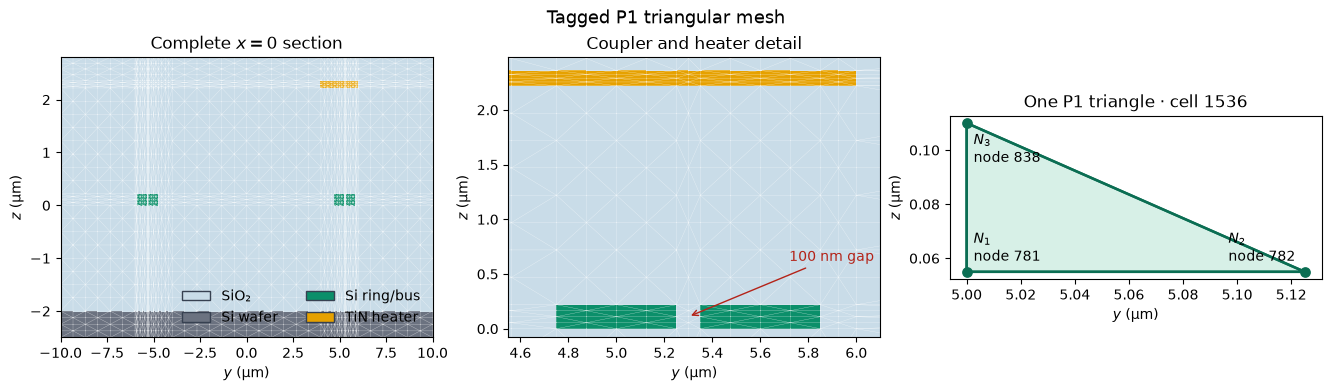

In [4]:
mesh_colors = ("#C9DCE8", "#6B7280", "#0B8F6A", "#0B8F6A", "#E6A100")
mesh_cmap = mpl.colors.ListedColormap(mesh_colors)
triangulation = mtri.Triangulation(
    coordinates[:, 0] * 1.0e6,
    coordinates[:, 1] * 1.0e6,
    cells,
)

fig, axes = plt.subplots(1, 3, figsize=(13.2, 3.8), constrained_layout=True)

for axis, limits, title in (
    (axes[0], ((-10.0, 10.0), (-2.5, 2.8)), "Complete $x=0$ section"),
    (axes[1], ((4.55, 6.10), (-0.08, 2.48)), "Coupler and heater detail"),
):
    axis.tripcolor(
        triangulation,
        facecolors=region_id,
        cmap=mesh_cmap,
        vmin=-0.5,
        vmax=4.5,
        shading="flat",
    )
    axis.triplot(triangulation, color="white", linewidth=0.22, alpha=0.72)
    axis.set(
        xlim=limits[0],
        ylim=limits[1],
        xlabel="$y$ (µm)",
        ylabel="$z$ (µm)",
        title=title,
    )

legend_handles = [
    mpl.patches.Patch(facecolor=mesh_colors[0], edgecolor="#374151", label="SiO₂"),
    mpl.patches.Patch(facecolor=mesh_colors[1], edgecolor="#374151", label="Si wafer"),
    mpl.patches.Patch(facecolor=mesh_colors[2], edgecolor="#374151", label="Si ring/bus"),
    mpl.patches.Patch(facecolor=mesh_colors[4], edgecolor="#374151", label="TiN heater"),
]
axes[0].legend(handles=legend_handles, loc="lower right", ncols=2, frameon=False)
axes[1].annotate(
    "100 nm gap",
    xy=(5.30, 0.11),
    xytext=(5.72, 0.62),
    arrowprops={"arrowstyle": "->", "color": "#B42318"},
    color="#B42318",
)

selected_cell = int(np.argmin((y_cell_um - 5.0) ** 2 + (z_cell_um - 0.11) ** 2))
selected_node_ids = cells[selected_cell]
selected_points_um = coordinates[selected_node_ids] * 1.0e6
closed_points = np.vstack((selected_points_um, selected_points_um[0]))
axes[2].fill(
    selected_points_um[:, 0],
    selected_points_um[:, 1],
    facecolor="#D7F0E7",
    edgecolor="#0B6E53",
    linewidth=1.8,
)
axes[2].plot(closed_points[:, 0], closed_points[:, 1], color="#0B6E53", linewidth=1.8)
label_offsets = ((5, 8), (-55, 8), (5, -28))
for local_index, (node_id, point) in enumerate(
    zip(selected_node_ids, selected_points_um, strict=True), start=1
):
    axes[2].scatter(*point, s=45, color="#0B6E53", zorder=3)
    axes[2].annotate(
        f"$N_{local_index}$\nnode {node_id}",
        xy=point,
        xytext=label_offsets[local_index - 1],
        textcoords="offset points",
    )
axes[2].set(
    aspect="equal",
    xlabel="$y$ (µm)",
    ylabel="$z$ (µm)",
    title=f"One P1 triangle · cell {selected_cell}",
)

fig.suptitle("Tagged P1 triangular mesh", fontsize=13)
plt.show()

## 6. Assemble the P1 system and Robin boundary

Material interfaces and source boundaries coincide with triangle edges, so each cell
has one constant $k$ and $q'''$. For a top edge of length $L$, the local Robin terms are

$$
K_\Gamma=\frac{hL}{6}
\begin{bmatrix}2&1\\1&2\end{bmatrix},\qquad
f_\Gamma=\frac{hT_\infty L}{2}
\begin{bmatrix}1\\1\end{bmatrix}
$$

The bottom heat sink is applied by symmetric strong elimination. The native tutorial
operator assembles a dense matrix; that is useful for inspecting a compact reference
problem, but it is not the intended storage model for future 3D FEM.

In [5]:
coordinates_jax = jnp.asarray(coordinates)
cells_jax = jnp.asarray(cells)
empty_facets = jnp.empty((0, 2), dtype=jnp.int64)
empty_facet_load = jnp.empty((0,), dtype=jnp.float64)
region_id_jax = jnp.asarray(region_id)

conductivities = jnp.asarray((1.38, 148.0, 148.0, 148.0, 28.0), dtype=jnp.float64)
cell_conductivity = conductivities[region_id_jax]
zero_source = jnp.zeros((cells.shape[0],), dtype=jnp.float64)
base_system = assemble_steady_heat_system(
    coordinates_jax,
    cells_jax,
    cell_conductivity,
    zero_source,
    empty_facets,
    empty_facet_load,
)

top_facets_jax = jnp.asarray(top_facets)
top_points = coordinates_jax[top_facets_jax]
top_lengths = jnp.linalg.norm(top_points[:, 1, :] - top_points[:, 0, :], axis=1)
robin_template = jnp.asarray(((2.0, 1.0), (1.0, 2.0)), dtype=jnp.float64)
robin_local = (HEAT["convection_W_per_m2K"] * top_lengths[:, None, None] / 6.0) * robin_template
robin_rows = jnp.repeat(top_facets_jax, 2, axis=1).reshape(-1)
robin_columns = jnp.tile(top_facets_jax, (1, 2)).reshape(-1)
stiffness = base_system.stiffness.at[robin_rows, robin_columns].add(robin_local.reshape(-1))
robin_load = jnp.zeros((coordinates.shape[0],), dtype=jnp.float64)
robin_nodal = HEAT["convection_W_per_m2K"] * HEAT["ambient_temperature_K"] * top_lengths / 2.0
robin_load = robin_load.at[top_facets_jax.reshape(-1)].add(jnp.repeat(robin_nodal, 2))

cell_areas, cell_gradients = triangle_p1_geometry(coordinates_jax, cells_jax)
heater_unit_load = jnp.zeros((coordinates.shape[0],), dtype=jnp.float64)
heater_local_load = jnp.where(region_id_jax == 4, cell_areas / 3.0, 0.0)
heater_unit_load = heater_unit_load.at[cells_jax.reshape(-1)].add(jnp.repeat(heater_local_load, 3))

bottom_nodes = jnp.arange(ny, dtype=jnp.int64)
bottom_values = jnp.full((ny,), HEAT["ambient_temperature_K"], dtype=jnp.float64)
free_node_mask = jnp.ones((coordinates.shape[0],), dtype=bool).at[bottom_nodes].set(False)
heater_width_m = DESIGN["heater_width_um"] * 1.0e-6
heater_height_m = DESIGN["heater_height_um"] * 1.0e-6
tin_sigma = MATERIALS["TiN"]["electrical_conductivity_S_per_m"]


def volumetric_heat(current_A):
    current_density = current_A / (heater_width_m * heater_height_m)
    return current_density**2 / tin_sigma


def state_for_current(current_A):
    source_load = volumetric_heat(current_A) * heater_unit_load
    unconstrained = AssembledScalarSystem(stiffness, robin_load + source_load)
    constrained = impose_dirichlet_constraints(
        unconstrained.stiffness,
        unconstrained.load,
        bottom_nodes,
        bottom_values,
    )
    return implicit_linear_solve(constrained.stiffness, constrained.load)


ring_weights = jnp.where(region_id_jax == 2, cell_areas, 0.0)
bus_weights = jnp.where(region_id_jax == 3, cell_areas, 0.0)
upper_ring_weights = jnp.where(
    (region_id_jax == 2) & (jnp.asarray(y_cell_um) > 0.0), cell_areas, 0.0
)
lower_ring_weights = jnp.where(
    (region_id_jax == 2) & (jnp.asarray(y_cell_um) < 0.0), cell_areas, 0.0
)
upper_bus_weights = jnp.where(
    (region_id_jax == 3) & (jnp.asarray(y_cell_um) > 0.0), cell_areas, 0.0
)
lower_bus_weights = jnp.where(
    (region_id_jax == 3) & (jnp.asarray(y_cell_um) < 0.0), cell_areas, 0.0
)


def ring_mean_delta_temperature(current_A):
    temperature = state_for_current(current_A)
    cell_temperature = jnp.mean(temperature[cells_jax], axis=1)
    mean_temperature = jnp.sum(ring_weights * cell_temperature) / jnp.sum(ring_weights)
    return mean_temperature - HEAT["ambient_temperature_K"]


state_for_current_jit = jax.jit(state_for_current)
objective_jit = jax.jit(ring_mean_delta_temperature)
objective_and_gradient_jit = jax.jit(jax.value_and_grad(ring_mean_delta_temperature))

q_reference = float(volumetric_heat(HEAT["current_A"]))
line_power_reference = q_reference * heater_area_m2
selected_cell_for_matrix = int(np.argmin((y_cell_um - 5.0) ** 2 + (z_cell_um - 0.11) ** 2))
selected_gradients = np.asarray(cell_gradients[selected_cell_for_matrix])
selected_local_stiffness = (
    float(np.asarray(cell_conductivity[selected_cell_for_matrix]))
    * float(np.asarray(cell_areas[selected_cell_for_matrix]))
    * (selected_gradients @ selected_gradients.T)
)
print(f"volumetric source : {q_reference:.9e} W/m³")
print(f"slice line power  : {line_power_reference:.9e} W/m")
print("sample element K  :")
print(np.array2string(selected_local_stiffness, precision=4, suppress_small=True))
print(f"row-sum check     : {np.max(np.abs(selected_local_stiffness.sum(axis=1))):.3e}")

volumetric source : 1.247781721e+15 W/m³
slice line power  : 3.493788820e+02 W/m
sample element K  :
[[ 200.7418  -32.56   -168.1818]
 [ -32.56     32.56      0.    ]
 [-168.1818    0.      168.1818]]
row-sum check     : 0.000e+00


## 7. Solve and check the discrete physics

A successful linear solve is not yet scientific validation. We separately check the
free-DOF residual, energy balance, enforced bottom temperature, and the discrete
minimum temperature. The notch leaves the heat source only above the positive-$y$
coupler, so the upper ring and bus should be warmer than their lower counterparts.
These checks validate the 2D discrete problem only; 3D and Elmer agreement remain
separate gates.

In [6]:
current = jnp.asarray(HEAT["current_A"], dtype=jnp.float64)
solve_start = time.perf_counter()
temperature = state_for_current_jit(current)
temperature.block_until_ready()
solve_elapsed_s = time.perf_counter() - solve_start

q_current = volumetric_heat(current)
physical_load = robin_load + q_current * heater_unit_load
unconstrained_residual = stiffness @ temperature - physical_load
residual_scale = jnp.maximum(jnp.linalg.norm(physical_load, ord=jnp.inf), 1.0e-30)
relative_free_residual = (
    jnp.linalg.norm(unconstrained_residual[free_node_mask], ord=jnp.inf) / residual_scale
)

input_line_power = q_current * jnp.sum(heater_unit_load)
bottom_removed = -jnp.sum(unconstrained_residual[bottom_nodes])
top_temperature = temperature[top_facets_jax]
convection_removed = HEAT["convection_W_per_m2K"] * jnp.sum(
    top_lengths * (jnp.mean(top_temperature, axis=1) - HEAT["ambient_temperature_K"])
)
relative_energy_error = jnp.abs(
    (bottom_removed + convection_removed - input_line_power) / input_line_power
)

peak_delta_temperature = jnp.max(temperature) - HEAT["ambient_temperature_K"]
minimum_temperature = jnp.min(temperature)
bottom_constraint_error = jnp.max(
    jnp.abs(temperature[bottom_nodes] - HEAT["ambient_temperature_K"])
)
cell_temperature = jnp.mean(temperature[cells_jax], axis=1)


def weighted_delta_temperature(weights, temperature_by_cell):
    mean_temperature = jnp.sum(weights * temperature_by_cell) / jnp.sum(weights)
    return mean_temperature - HEAT["ambient_temperature_K"]


upper_ring_delta = weighted_delta_temperature(upper_ring_weights, cell_temperature)
lower_ring_delta = weighted_delta_temperature(lower_ring_weights, cell_temperature)
upper_bus_delta = weighted_delta_temperature(upper_bus_weights, cell_temperature)
lower_bus_delta = weighted_delta_temperature(lower_bus_weights, cell_temperature)

CHECKS = {
    "relative_free_residual": float(relative_free_residual),
    "relative_energy_error": float(relative_energy_error),
    "bottom_constraint_error_K": float(bottom_constraint_error),
    "minimum_temperature_K": float(minimum_temperature),
    "maximum_temperature_K": float(jnp.max(temperature)),
    "peak_delta_temperature_K": float(peak_delta_temperature),
    "upper_ring_mean_delta_K": float(upper_ring_delta),
    "lower_ring_mean_delta_K": float(lower_ring_delta),
    "upper_bus_mean_delta_K": float(upper_bus_delta),
    "lower_bus_mean_delta_K": float(lower_bus_delta),
    "input_line_power_W_per_m": float(input_line_power),
    "bottom_removed_W_per_m": float(bottom_removed),
    "convection_removed_W_per_m": float(convection_removed),
    "solve_elapsed_s_including_first_compile": solve_elapsed_s,
}
assert CHECKS["relative_free_residual"] < 2.0e-9
assert CHECKS["relative_energy_error"] < 2.0e-9
assert CHECKS["bottom_constraint_error_K"] < 2.0e-10
assert CHECKS["minimum_temperature_K"] >= 300.0 - 2.0e-8
assert CHECKS["upper_ring_mean_delta_K"] > CHECKS["lower_ring_mean_delta_K"] > 0.0
assert CHECKS["upper_bus_mean_delta_K"] > CHECKS["lower_bus_mean_delta_K"] > 0.0

for key, value in CHECKS.items():
    print(f"{key:41s}: {value:.9e}")

relative_free_residual                   : 2.399086952e-11
relative_energy_error                    : 1.403274534e-12
bottom_constraint_error_K                : 0.000000000e+00
minimum_temperature_K                    : 3.000000000e+02
maximum_temperature_K                    : 4.613675492e+02
peak_delta_temperature_K                 : 1.613675492e+02
upper_ring_mean_delta_K                  : 6.218529092e+01
lower_ring_mean_delta_K                  : 4.061156133e+00
upper_bus_mean_delta_K                   : 6.192784138e+01
lower_bus_mean_delta_K                   : 3.745886177e+00
input_line_power_W_per_m                 : 3.493788820e+02
bottom_removed_W_per_m                   : 3.493682197e+02
convection_removed_W_per_m               : 1.066230036e-02
solve_elapsed_s_including_first_compile  : 3.835602600e-01


## 8. Differentiate the converged FEM state

The objective is the area-weighted mean temperature rise in the silicon ring
section. `jax.value_and_grad` calls femx's `implicit_linear_solve` custom VJP,
which solves the transposed linear system instead of tracing through every solver
operation.

We check the reverse-mode result independently in two ways: a central finite
difference at $I\pm5\%$ and the quadratic identity implied by
$q'''\propto I^2$.

In [7]:
gradient_start = time.perf_counter()
ring_delta_temperature, reverse_gradient = objective_and_gradient_jit(current)
reverse_gradient.block_until_ready()
gradient_elapsed_s = time.perf_counter() - gradient_start

finite_difference_step = 0.05 * current
objective_plus = objective_jit(current + finite_difference_step)
objective_minus = objective_jit(current - finite_difference_step)
finite_difference_gradient = (objective_plus - objective_minus) / (2.0 * finite_difference_step)
finite_difference_gradient.block_until_ready()

relative_gradient_error = jnp.abs(reverse_gradient - finite_difference_gradient) / jnp.maximum(
    jnp.abs(finite_difference_gradient), 1.0e-30
)
quadratic_identity_error = jnp.abs(
    ring_delta_temperature - 0.5 * current * reverse_gradient
) / jnp.maximum(jnp.abs(ring_delta_temperature), 1.0e-30)

ADJOINT = {
    "ring_mean_delta_temperature_K": float(ring_delta_temperature),
    "reverse_gradient_K_per_A": float(reverse_gradient),
    "finite_difference_gradient_K_per_A": float(finite_difference_gradient),
    "relative_gradient_error": float(relative_gradient_error),
    "quadratic_identity_error": float(quadratic_identity_error),
    "gradient_elapsed_s_including_first_compile": gradient_elapsed_s,
}
assert ADJOINT["relative_gradient_error"] < 2.0e-8
assert ADJOINT["quadratic_identity_error"] < 2.0e-8

for key, value in ADJOINT.items():
    print(f"{key:47s}: {value:.9e}")

ring_mean_delta_temperature_K                  : 3.312322353e+01
reverse_gradient_K_per_A                       : 4.416429803e+03
finite_difference_gradient_K_per_A             : 4.416429803e+03
relative_gradient_error                        : 2.471212474e-15
quadratic_identity_error                       : 4.611857377e-12
gradient_elapsed_s_including_first_compile     : 4.396841520e-01


## 9. Read the design and heat flow together

The upper panels show the complete analytic silicon and TiN plan views. The lower
panels show the actual $x=0$ finite-element section. Arrows indicate the direction
of $-k\nabla T$; their lengths are normalized for legibility, and cells below 0.1%
of the peak flux are hidden. Arrow length therefore does not encode absolute heat
flux.

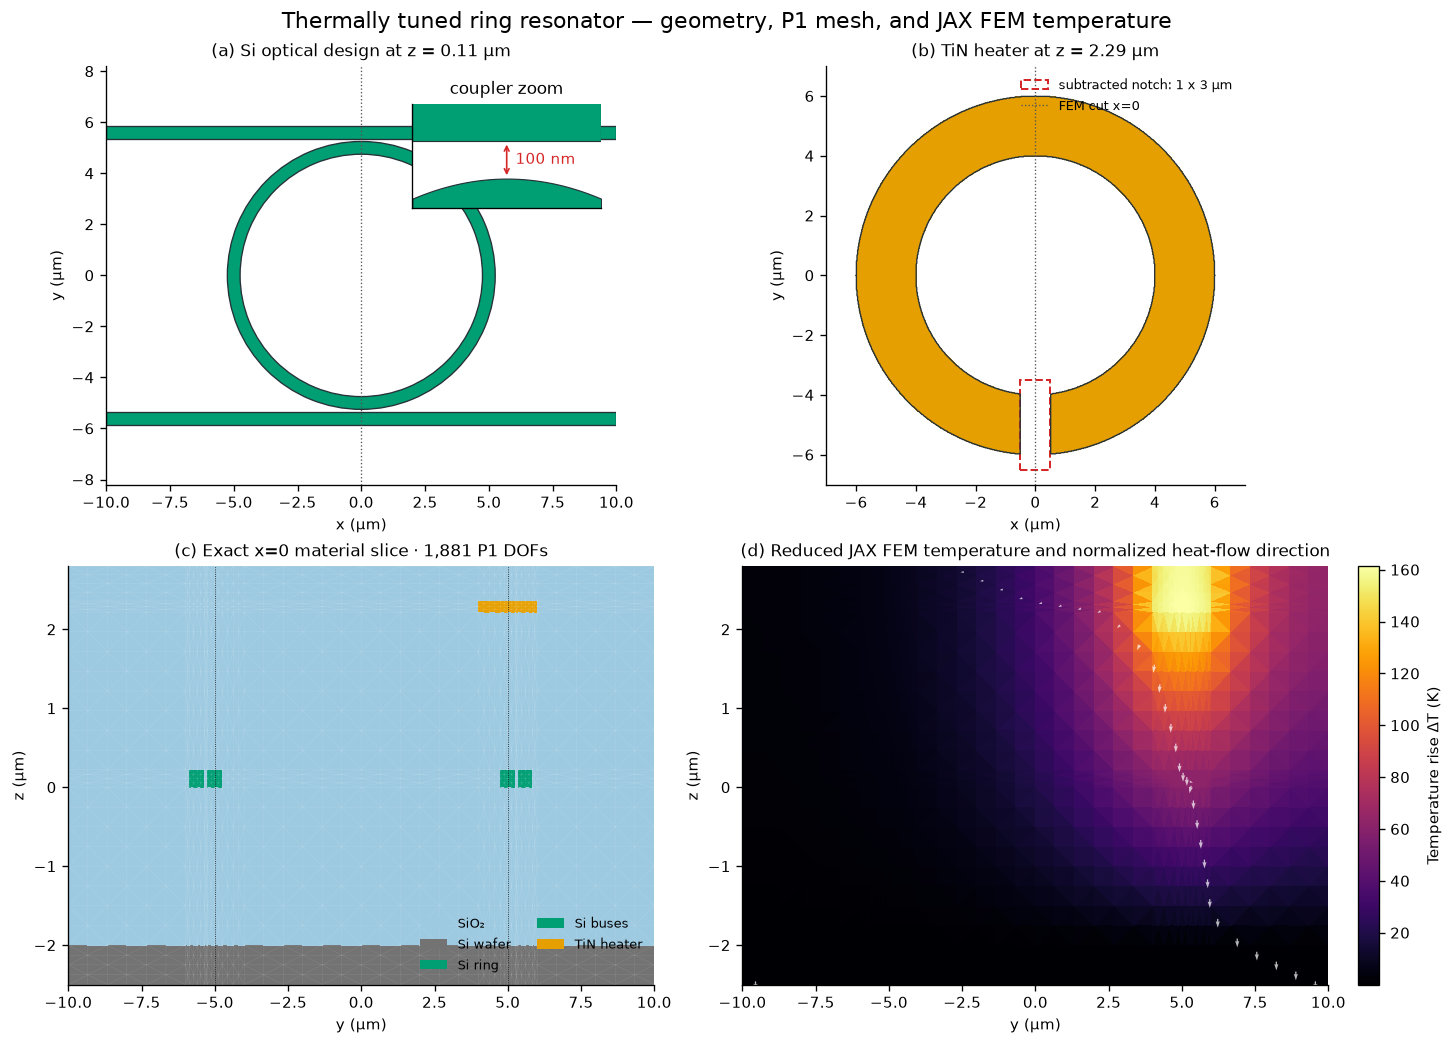

12

In [8]:
mpl.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 160,
        "font.size": 9,
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "legend.fontsize": 8,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)
colors = {
    "SiO2": "#9ecae1",
    "Si": "#009e73",
    "TiN": "#e69f00",
    "outline": "#263238",
}

fig, axes = plt.subplots(2, 2, figsize=(12.0, 8.6), constrained_layout=True)

ax = axes[0, 0]
ax.add_patch(
    Wedge(
        (0.0, 0.0),
        5.25,
        0.0,
        360.0,
        width=0.5,
        facecolor=colors["Si"],
        edgecolor=colors["outline"],
        linewidth=0.8,
    )
)
for center_y in DESIGN["bus_center_y_um"]:
    ax.add_patch(
        Rectangle(
            (-10.0, center_y - 0.25),
            20.0,
            0.5,
            facecolor=colors["Si"],
            edgecolor=colors["outline"],
            linewidth=0.8,
        )
    )
ax.set(
    xlim=(-10.0, 10.0),
    ylim=(-8.2, 8.2),
    aspect="equal",
    xlabel="x (µm)",
    ylabel="y (µm)",
    title="(a) Si optical design at z = 0.11 µm",
)
ax.axvline(0.0, color="#555555", linewidth=0.8, linestyle=":")
coupler_x = np.linspace(-0.75, 0.75, 301)
ring_outer_y = np.sqrt(5.25**2 - coupler_x**2)
ring_inner_y = np.sqrt(4.75**2 - coupler_x**2)
coupler_inset = ax.inset_axes((0.60, 0.66, 0.37, 0.25))
coupler_inset.fill_between(
    coupler_x,
    ring_inner_y,
    ring_outer_y,
    facecolor=colors["Si"],
    edgecolor=colors["outline"],
    linewidth=0.7,
)
coupler_inset.axhspan(
    5.35,
    5.85,
    facecolor=colors["Si"],
    edgecolor=colors["outline"],
    linewidth=0.7,
)
coupler_inset.annotate(
    "",
    xy=(0.0, 5.25),
    xytext=(0.0, 5.35),
    arrowprops={"arrowstyle": "<->", "color": "#d62728", "mutation_scale": 7},
)
coupler_inset.text(0.07, 5.30, "100 nm", color="#d62728", va="center")
coupler_inset.set(
    xlim=(-0.75, 0.75),
    ylim=(5.17, 5.45),
    xticks=(),
    yticks=(),
    title="coupler zoom",
)

ax = axes[0, 1]
plan_axis = np.linspace(-7.0, 7.0, 701)
plan_x, plan_y = np.meshgrid(plan_axis, plan_axis, indexing="xy")
heater_mask = heater_plan_mask(plan_x, plan_y)
ax.contourf(
    plan_x,
    plan_y,
    heater_mask.astype(float),
    levels=(0.5, 1.5),
    colors=(colors["TiN"],),
)
ax.contour(
    plan_x,
    plan_y,
    heater_mask.astype(float),
    levels=(0.5,),
    colors=(colors["outline"],),
    linewidths=(0.8,),
)
ax.add_patch(
    Rectangle(
        (-0.5, -6.5),
        1.0,
        3.0,
        fill=False,
        edgecolor="#d62728",
        linewidth=1.2,
        linestyle="--",
        label="subtracted notch: 1 x 3 µm",
    )
)
ax.axvline(0.0, color="#555555", linewidth=0.8, linestyle=":", label="FEM cut x=0")
ax.legend(loc="upper right", frameon=False)
ax.set(
    xlim=(-7.0, 7.0),
    ylim=(-7.0, 7.0),
    aspect="equal",
    xlabel="x (µm)",
    ylabel="y (µm)",
    title="(b) TiN heater at z = 2.29 µm",
)

triangulation = mtri.Triangulation(
    coordinates[:, 0] * 1.0e6,
    coordinates[:, 1] * 1.0e6,
    cells,
)
region_cmap = mpl.colors.ListedColormap(
    (colors["SiO2"], "#737373", colors["Si"], colors["Si"], colors["TiN"])
)
ax = axes[1, 0]
ax.tripcolor(
    triangulation,
    facecolors=region_id,
    cmap=region_cmap,
    vmin=-0.5,
    vmax=4.5,
    shading="flat",
)
ax.triplot(triangulation, color="#ffffff", linewidth=0.08, alpha=0.42)
ax.axvline(-5.0, color="#111111", linewidth=0.5, linestyle=":")
ax.axvline(5.0, color="#111111", linewidth=0.5, linestyle=":")
legend_handles = [
    mpl.patches.Patch(facecolor=colors["SiO2"], label="SiO₂"),
    mpl.patches.Patch(facecolor="#737373", label="Si wafer"),
    mpl.patches.Patch(facecolor=colors["Si"], label="Si ring"),
    mpl.patches.Patch(facecolor=colors["Si"], label="Si buses"),
    mpl.patches.Patch(facecolor=colors["TiN"], label="TiN heater"),
]
ax.legend(handles=legend_handles, loc="lower right", ncols=2, frameon=False)
ax.set(
    xlim=(-10.0, 10.0),
    ylim=(-2.5, 2.8),
    xlabel="y (µm)",
    ylabel="z (µm)",
    title=f"(c) Exact x=0 material slice · {coordinates.shape[0]:,} P1 DOFs",
)

cell_temperature = np.asarray(temperature)[cells].mean(axis=1)
gradient_temperature = np.einsum(
    "ci,cid->cd",
    np.asarray(temperature)[cells],
    np.asarray(cell_gradients),
)
cell_conductivity_np = np.asarray(cell_conductivity)
heat_flux = -cell_conductivity_np[:, None] * gradient_temperature
flux_norm = np.linalg.norm(heat_flux, axis=1)

ax = axes[1, 1]
temperature_plot = ax.tripcolor(
    triangulation,
    facecolors=cell_temperature - HEAT["ambient_temperature_K"],
    cmap="inferno",
    shading="flat",
)
sample_candidates = np.arange(0, cells.shape[0], 110)
flux_cutoff = 1.0e-3 * np.max(flux_norm)
sample = sample_candidates[flux_norm[sample_candidates] >= flux_cutoff]
safe_flux = heat_flux[sample] / np.maximum(flux_norm[sample, None], 1.0e-30)
ax.quiver(
    y_cell_um[sample],
    z_cell_um[sample],
    safe_flux[:, 0],
    safe_flux[:, 1],
    color="white",
    alpha=0.72,
    angles="xy",
    scale_units="xy",
    scale=9.0,
    width=0.0022,
    headwidth=3.2,
)
colorbar = fig.colorbar(temperature_plot, ax=ax, pad=0.02)
colorbar.set_label("Temperature rise ΔT (K)")
ax.set(
    xlim=(-10.0, 10.0),
    ylim=(-2.5, 2.8),
    xlabel="y (µm)",
    ylabel="z (µm)",
    title="(d) Reduced JAX FEM temperature and normalized heat-flow direction",
)

fig.suptitle(
    "Thermally tuned ring resonator — geometry, P1 mesh, and JAX FEM temperature",
    fontsize=13,
)
plt.show()

del cell_temperature, gradient_temperature, heat_flux, flux_norm, safe_flux
gc.collect()

## 10. What this result establishes

This executed notebook supports four narrow claims:

1. The analytic reconstruction preserves the published MRR dimensions and heater
   notch.
2. The fixed $x=0$ section preserves the ring, both buses, both coupling gaps, and
   the one-sided heater created by the notch.
3. The float64 JAX P1 solution passes residual, energy-balance, boundary, and
   temperature-ordering checks.
4. The implicit reverse gradient of the ring-mean temperature agrees with a central
   finite difference.

The published optical stage uses a $14\times14\times3\ \mu\mathrm m$ domain, a
$1.5$-$1.6\ \mu\mathrm m$ wavelength sweep, a mode source on the left of the upper
bus, through/drop monitors, and a bend-mode plane with a $5\ \mu\mathrm m$ radius.
Its thermal field changes the optical properties of both the ring and the buses.
An FDTDX handoff therefore needs a 3D temperature artifact over the complete optical
domain, not this 2D picture. Cropping away the heater and wafer outside the EM domain,
while preserving material invariance normal to each PML, must be an explicit and
tested transformation.

### Next verification gates

- Generate one canonical tetrahedral mesh and semantic tags from the same 3D CAD.
- Run Elmer steady heat on the **same mesh, properties, boundaries, and source**.
- Compare native JAX Tet4 assembled or matrix-free operators under mesh refinement.
- Convert the temperature-dependent refractive index into a complex mode artifact,
  then transfer it to the FDTDX Yee grid while checking power and phase.
- Check the complete FEM thermal adjoint plus FDTDX reverse-gradient chain against
  finite differences of the final optical objective.

This notebook is therefore a visual and differentiable vertical slice, not evidence
of completed 3D Elmer parity or device-level prediction.

In [9]:
EVIDENCE = {
    "schema_version": "femx.example.thermally_tuned_ring_fem.evidence/v1",
    "design_schema_version": design_record["schema_version"],
    "design_sha256": DESIGN_SHA256,
    "backend": RUNTIME["backend"],
    "float64": RUNTIME["float64"],
    "model_dimension": "2D",
    "model_slice": "x=0 vertical y-z solid slice",
    "mesh_profile": MESH_PROFILE,
    "current_mA": HEAT["current_A"] * 1.0e3,
    "node_count": int(coordinates.shape[0]),
    "triangle_count": int(cells.shape[0]),
    "full_3d_parity_claimed": False,
    "elmer_parity_claimed": False,
    "checks": CHECKS,
    "adjoint": ADJOINT,
}
print("FEMX_THERMALLY_TUNED_RING_EVIDENCE=" + json.dumps(EVIDENCE, sort_keys=True))

FEMX_THERMALLY_TUNED_RING_EVIDENCE={"adjoint": {"finite_difference_gradient_K_per_A": 4416.429803466826, "gradient_elapsed_s_including_first_compile": 0.43968415200004074, "quadratic_identity_error": 4.611857376799522e-12, "relative_gradient_error": 2.471212474091148e-15, "reverse_gradient_K_per_A": 4416.429803466837, "ring_mean_delta_temperature_K": 33.123223525848516}, "backend": "gpu", "checks": {"bottom_constraint_error_K": 0.0, "bottom_removed_W_per_m": 349.36821968672757, "convection_removed_W_per_m": 0.010662300359553012, "input_line_power_W_per_m": 349.3788819875774, "lower_bus_mean_delta_K": 3.7458861765941265, "lower_ring_mean_delta_K": 4.061156132573842, "maximum_temperature_K": 461.3675491934916, "minimum_temperature_K": 300.0, "peak_delta_temperature_K": 161.36754919349158, "relative_energy_error": 1.4032745336104814e-12, "relative_free_residual": 2.3990869522094544e-11, "solve_elapsed_s_including_first_compile": 0.38356025999996746, "upper_bus_mean_delta_K": 61.9278413777